# Imports

In [1]:
import importlib
import sys
import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')

# Data

### Load Data Files

In [2]:
# Path to your pickle file (saved with torch.save)
file_path_train = '../../../../encoded_data/BPIC20/BPIC_2020_all_5_train.pkl'
# Load the dataset using torch.load
BPIC_20_train_dataset = torch.load(file_path_train, weights_only=False)
# Check the type of the loaded dataset
print(type(BPIC_20_train_dataset))

# Path to your pickle file (saved with torch.save)
file_path_val = '../../../../encoded_data/BPIC20/BPIC_2020_all_5_val.pkl'
# Load the dataset using torch.load
BPIC_20_val_dataset = torch.load(file_path_val, weights_only=False)
# Check the type of the loaded dataset
print(type(BPIC_20_val_dataset))

<class 'event_log_loader.new_event_log_loader.EventLogDataset'>
<class 'event_log_loader.new_event_log_loader.EventLogDataset'>


### Train Data Insights

In [3]:
# BPIC 20 Dataset Categories, Features:

bpic_20_all_categories = BPIC_20_train_dataset.all_categories

bpic_20_all_categories_cat = bpic_20_all_categories[0]
print(bpic_20_all_categories_cat)

bpic_20_all_categories_num = bpic_20_all_categories[1]
print(bpic_20_all_categories_num)

for i, cat in enumerate(bpic_20_all_categories_cat):
     print(f"BPIC 20 (5) Categorical feature: {cat[0]}, Index position in categorical data list: {i}")
     print(f"BPIC 20 (5) Total Amount of Category labels: {cat[1]}")
print('\n')    
for i, num in enumerate(bpic_20_all_categories_num):
     print(f"BPIC 20 (5) Numerical feature: {num[0]}, Index position in categorical data list: {i}")
     print(f"BPIC 20 (5) Amount Category Lables: {num[1]}")

[('concept:name', 18, {'Declaration APPROVED by ADMINISTRATION': 1, 'Declaration APPROVED by BUDGET OWNER': 2, 'Declaration APPROVED by PRE_APPROVER': 3, 'Declaration FINAL_APPROVED by SUPERVISOR': 4, 'Declaration FOR_APPROVAL by PRE_APPROVER': 5, 'Declaration FOR_APPROVAL by SUPERVISOR': 6, 'Declaration REJECTED by ADMINISTRATION': 7, 'Declaration REJECTED by BUDGET OWNER': 8, 'Declaration REJECTED by EMPLOYEE': 9, 'Declaration REJECTED by MISSING': 10, 'Declaration REJECTED by PRE_APPROVER': 11, 'Declaration REJECTED by SUPERVISOR': 12, 'Declaration SAVED by EMPLOYEE': 13, 'Declaration SUBMITTED by EMPLOYEE': 14, 'EOS': 15, 'Payment Handled': 16, 'Request Payment': 17}), ('org:resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3}), ('org:role', 9, {'ADMINISTRATION': 1, 'BUDGET OWNER': 2, 'EMPLOYEE': 3, 'EOS': 4, 'MISSING': 5, 'PRE_APPROVER': 6, 'SUPERVISOR': 7, 'UNDEFINED': 8}), ('case:BudgetNumber', 3, {'EOS': 1, 'budget 86566': 2}), ('case:DeclarationNumber', 6535, {'EOS': 1, 'U

### Input Features for Encoder and Decoder

In [4]:
# Create lists with name of Encoder features (input) and decoder features (input & output)

# Encoder features:
enc_feat_cat = []
enc_feat_num = []
for cat in bpic_20_all_categories_cat:
    enc_feat_cat.append(cat[0])
for num in bpic_20_all_categories_num:
    enc_feat_num.append(num[0])
enc_feat = [enc_feat_cat, enc_feat_num]
print("Input features encoder: ", enc_feat)

"""
# Decoder features:
dec_feat_cat = enc_feat_cat
dec_feat_num = enc_feat_num
dec_feat = [dec_feat_cat, dec_feat_num]
print("Features decoder: ", dec_feat)
"""

# Decoder features:
dec_feat_cat = ['concept:name']
dec_feat_num = ['case_elapsed_time']
dec_feat = [dec_feat_cat, dec_feat_num]
print("Features decoder: ", dec_feat)

# dec_feat_cat = ['concept:name', 'org:resource', 'org:role']
# dec_feat_num = ['case_elapsed_time', 'event_elapsed_time']
# dec_feat = [dec_feat_cat, dec_feat_num]
# print("Features decoder: ", dec_feat)

Input features encoder:  [['concept:name', 'org:resource', 'org:role', 'case:BudgetNumber', 'case:DeclarationNumber'], ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day']]
Features decoder:  [['concept:name'], ['case_elapsed_time']]


# Model

In [5]:
import model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model
importlib.reload(model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model)
from model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM

# Prediction decoder output sequence length
seq_len_pred = 4

# Size hidden layer
hidden_size = 128

# Number of cells
num_layers = 4

# Fixed Dropout probability 
dropout = 0.1

# Encoder Decoder model initialization
model = DropoutUncertaintyEncoderDecoderLSTM(data_set_categories=bpic_20_all_categories,
                                             enc_feat=enc_feat,
                                             dec_feat=dec_feat,
                                             seq_len_pred=seq_len_pred,
                                             hidden_size=hidden_size,
                                             num_layers=num_layers,
                                             dropout=dropout)

Data set categories:  ([('concept:name', 18, {'Declaration APPROVED by ADMINISTRATION': 1, 'Declaration APPROVED by BUDGET OWNER': 2, 'Declaration APPROVED by PRE_APPROVER': 3, 'Declaration FINAL_APPROVED by SUPERVISOR': 4, 'Declaration FOR_APPROVAL by PRE_APPROVER': 5, 'Declaration FOR_APPROVAL by SUPERVISOR': 6, 'Declaration REJECTED by ADMINISTRATION': 7, 'Declaration REJECTED by BUDGET OWNER': 8, 'Declaration REJECTED by EMPLOYEE': 9, 'Declaration REJECTED by MISSING': 10, 'Declaration REJECTED by PRE_APPROVER': 11, 'Declaration REJECTED by SUPERVISOR': 12, 'Declaration SAVED by EMPLOYEE': 13, 'Declaration SUBMITTED by EMPLOYEE': 14, 'EOS': 15, 'Payment Handled': 16, 'Request Payment': 17}), ('org:resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3}), ('org:role', 9, {'ADMINISTRATION': 1, 'BUDGET OWNER': 2, 'EMPLOYEE': 3, 'EOS': 4, 'MISSING': 5, 'PRE_APPROVER': 6, 'SUPERVISOR': 7, 'UNDEFINED': 8}), ('case:BudgetNumber', 3, {'EOS': 1, 'budget 86566': 2}), ('case:DeclarationNumbe

# Loss Object Creation

In [6]:
import loss.losses
importlib.reload(loss.losses)
from loss.losses import Loss

loss_obj = Loss()

# Training Configuration

In [7]:
import trainer.trainer
importlib.reload(trainer.trainer)
from trainer.trainer import Trainer
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(comment="Full_BPIC20_grad")

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Start learning rate
learning_rate = 1e-5

# Optimizer and Scheduler
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate, weight_decay=0)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, min_lr=1e-10)

# Epochs
num_epochs = 100

# Batch size
batch_size = 128

# lambda for L2 (weight, bias, dropout) regularization: According to formula: 1/2N
# regularization_term = 1.0/(2.0*batch_size)
regularization_term = 1e-4

# shuffle data
shuffle = True

# Teacher forcing: Smaller 0.5 more target events are used for next event prediction.
teacher_forcing_ratio = 0.8

optimize_values = {"regularization_term":regularization_term,
                   "optimizer":optimizer,
                   "scheduler": scheduler,
                   "epochs":num_epochs,
                   "mini_batches":batch_size,
                   "shuffle": shuffle,
                   "teacher_forcing_ratio":teacher_forcing_ratio,}

suffix_data_split_value = 4

# GradNorm parameter
use_gradnorm = True
gn_alpha = 1.5
gn_learning_rate = 1e-4

number_tasks = len(dec_feat[0]) + len(dec_feat[1])

gradNorm = {"use_gradnorm":use_gradnorm,
            "number_tasks": number_tasks,
            "gn_alpha":gn_alpha,
            "gn_learning_rate": gn_learning_rate}

trainer = Trainer(device=device,
                  model=model,
                  data_train=BPIC_20_train_dataset,
                  data_val=BPIC_20_val_dataset,
                  loss_obj=loss_obj,
                  log_normal_loss_num_feature= [],
                  optimize_values=optimize_values,
                  suffix_data_split_value=suffix_data_split_value,
                  writer=writer,
                  gradnorm_values=gradNorm,
                  save_model_n_th_epoch = 1,
                  saving_path = 'BPIC_2020_setting_2_2.pkl')

# Train the model:
train_attenuated_losses, val_losses, val_attenuated_losses = trainer.train_model()

Device:  cuda
Model:  DropoutUncertaintyEncoderDecoderLSTM(
  (embeddings_enc): ModuleList(
    (0): Embedding(18, 8)
    (1): Embedding(4, 3)
    (2): Embedding(9, 5)
    (3): Embedding(3, 3)
    (4): Embedding(6535, 219)
  )
  (encoder): DropoutUncertaintyLSTMEncoder(
    (embeddings): ModuleList(
      (0): Embedding(18, 8)
      (1): Embedding(4, 3)
      (2): Embedding(9, 5)
      (3): Embedding(3, 3)
      (4): Embedding(6535, 219)
    )
    (first_layer): DropoutUncertaintyLSTMCell(
      (Wi): Linear(in_features=242, out_features=128, bias=True)
      (Ui): Linear(in_features=128, out_features=128, bias=True)
      (Wf): Linear(in_features=242, out_features=128, bias=True)
      (Uf): Linear(in_features=128, out_features=128, bias=True)
      (Wc): Linear(in_features=242, out_features=128, bias=True)
      (Uc): Linear(in_features=128, out_features=128, bias=True)
      (Wo): Linear(in_features=242, out_features=128, bias=True)
      (Uo): Linear(in_features=128, out_features=1

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch [1/100], Learning Rate: 1e-05, Teacher forcing ratio: 0.8
Training: Avg Attenuated Training Loss: 4.1658


Validation: Avg Standard Validation Loss: 6.2888
Validation: Avg Attenuated Validation Loss: 5.0214
Validation Loss for Scheduler: 6.2888
saving model


Epoch [2/100], Learning Rate: 1e-05, Teacher forcing ratio: 0.8
Training: Avg Attenuated Training Loss: 3.6971


...

Validation: Avg Standard Validation Loss: 4.7282
Validation: Avg Attenuated Validation Loss: 122.8289
Validation Loss for Scheduler: 4.7282
saving model


Epoch [99/100], Learning Rate: 1.0000000000000004e-08, Teacher forcing ratio: 0.679477248
Training: Avg Attenuated Training Loss: 0.7474


Validation: Avg Standard Validation Loss: 4.7267
Validation: Avg Attenuated Validation Loss: 108.9057
Validation Loss for Scheduler: 4.7267
saving model


Epoch [100/100], Learning Rate: 1.0000000000000004e-08, Teacher forcing ratio: 0.679477248
Training: Avg Attenuated Training Loss: 0.8254


Validation: Avg Standard Validation Loss: 4.7167
Validation: Avg Attenuated Validation Loss: 104.7454
Validation Loss for Scheduler: 4.7167
saving model
Training complete.
Model saved to path: BPIC_2020_setting_2_2.pkl


# Training Visualization

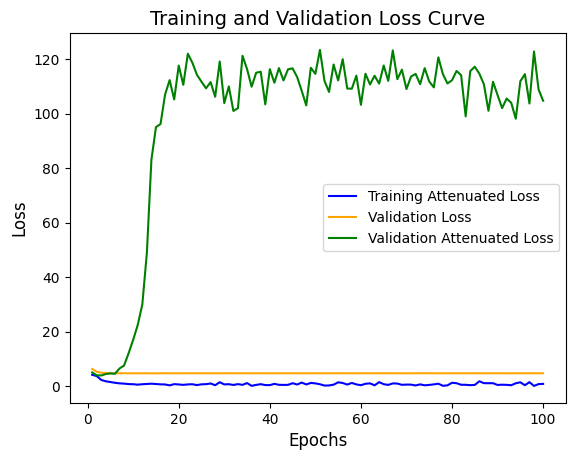

In [8]:
import matplotlib.pyplot as plt

# After training is finished, plot the loss curves
plt.plot(range(1, num_epochs+1), train_attenuated_losses, label='Training Attenuated Loss', color='blue')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss', color='orange')
plt.plot(range(1, num_epochs+1), val_attenuated_losses, label='Validation Attenuated Loss', color='green')
# Labeling x and y axes
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
# Adding title
plt.title('Training and Validation Loss Curve', fontsize=14)
# Adding legend
plt.legend()
# Show the plot
plt.show()